In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Task 1: Data Loading & Exploration

In [2]:
#Data Loading
df=pd.read_csv("Housing.csv")
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [3]:
#Top 10 rows
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
#Rows and Columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
print("Target column: ", df.columns[0])
print("Features: ", df.columns[1:])

Target column:  price
Features:  Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')


In [6]:
#Missing or null values
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

## Task 2: Data Cleaning

In [7]:
# No missing values

In [8]:
# Duplicates
df.duplicated().sum() # No duplicates found

0

In [9]:
# Conversion
df_encoded=pd.get_dummies(df, drop_first=True, dtype=int)

In [10]:
df_encoded

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2,1,0,1,0,0,0,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,1750000,3620,2,1,1,0,1,0,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0,0


In [11]:
#Checking the important columns
correlation= df_encoded.corr()[['price']].sort_values('price', ascending=False)

In [12]:
correlation

,price
price,1.000000
area,0.535997
bathrooms,0.517545
airconditioning_yes,0.452954
stories,0.420712
parking,0.384394
bedrooms,0.366494
prefarea_yes,0.329777
mainroad_yes,0.296898
guestroom_yes,0.255517


#### The above correlation shows that all the columns are important for the ML Model, hence we consider all the columns

## Task 3: Model Building

In [13]:
# Splitting data
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [14]:
x=df_encoded.drop('price',axis=1)
x

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,7420,4,1,2,2,1,1,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,2,1,0,1,0,0,0,0,1
541,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,3620,2,1,1,0,1,0,0,0,0,0,0,1
543,2910,3,1,1,0,0,0,0,0,0,0,0,0


In [15]:
y=df_encoded['price']
y

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64

In [16]:
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.2, random_state=42) 

In [17]:
#Training the model
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [18]:
#Evaluation
pred=lr.predict(x_test)

In [19]:
from sklearn.metrics import *
print("R2 Score:", r2_score(y_test,pred))
print("MAE:", mean_absolute_error(y_test,pred ))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

R2 Score: 0.6529242642153185
MAE: 970043.4039201641
RMSE: 1324506.9600914384


In [20]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(random_state=42)

In [21]:
rf.fit(x_train, y_train)


RandomForestRegressor(random_state=42)

In [22]:
pred_rf=rf.predict(x_test)

In [23]:
print("R2 Score:", r2_score(y_test,pred_rf))
print("MAE:", mean_absolute_error(y_test,pred_rf ))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))

R2 Score: 0.611918531405699
MAE: 1021546.0353211008
RMSE: 1400565.9728553821


In [24]:
print("Linear Regression r2_score: ", r2_score(y_test,pred))
print("Random Forest Regressor r2_score: ", r2_score(y_test,pred_rf))

Linear Regression r2_score:  0.6529242642153185
Random Forest Regressor r2_score:  0.611918531405699


### Task 4: Visualization

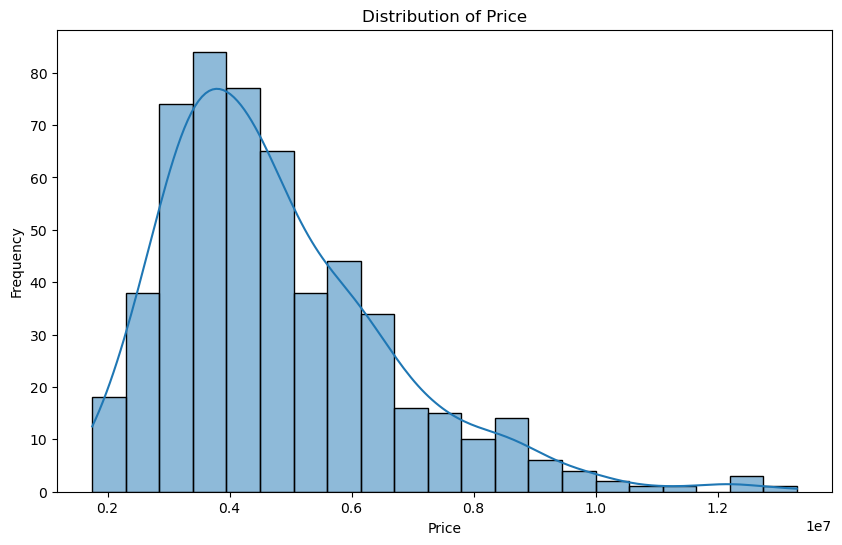

In [25]:
#Chart 1
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='price', kde=True)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of Price")
plt.savefig("Chart_1.png")
plt.show()

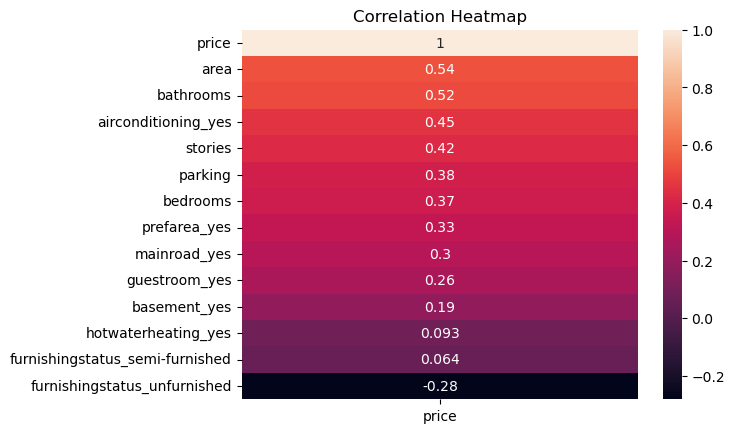

In [26]:
#Chart2
sns.heatmap(df_encoded.corr()[['price']].sort_values('price',ascending=False),annot=True)
plt.title('Correlation Heatmap')
plt.savefig("Chart_2.png")
plt.show()

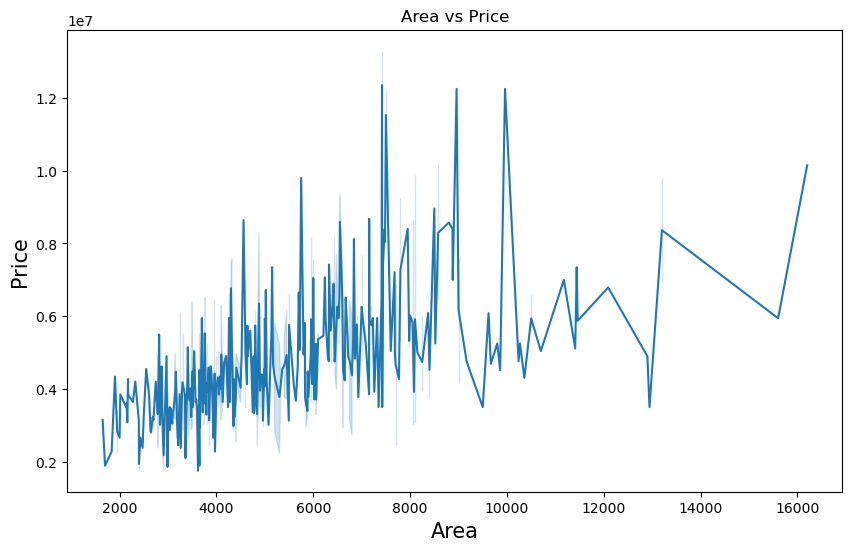

In [27]:
#Chart3
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='area', y='price')
plt.xlabel("Area", fontsize=15)
plt.ylabel("Price", fontsize=15)
plt.title("Area vs Price")
plt.savefig("Chart_3.png")
plt.show()

## Task 5: Insights and Summary

#### Most influencing features: Overall all of the features were important for the model building, as all of their values were greater than 0. The feature that had the least correlation value is the "furnishing_status_unfurnished", due to the one hot encoding that added 2 columns for the column as it had 3 categories, so the column "furnishing_status" was important in model and was not dropped. But if we were to select the MOST important columns, they would be "area" and "bathrooms" as people often look at the area and no. of bathrooms.

#### The accuracy of ML model: If we look into the r2 score of Linear Regression Model, we get 65.29%, which is actually a fair good percentage for Regression model. I had tried to remove some features like "hotwaterheating" but the value dropped further, hence I kept the same amount of features and 65% was the maximum value I got with Linear Regression. With Random Forest Regressor, I got much less value than Linear Regression. So I think Linear Regression model is fairly better accurate than Random Forest Regressor.

#### I was surprised that the data neither had any null, missing or duplicate values. As most datasets often do have some null, missing or duplicate values, but this did not have any. So I was surprised to see this.

#### One recommendation that I would give to real estate businesses would be that, the price of a house is mostly affected by the area, bathrooms,  whether it has airconditioning and whether it is furnished or not. According to my findings, People mostly look for bigger areas and greater no. of bathrooms when looking for a house.